In [15]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import lib.dataloader as dl
import lib.datasplit as ds
import lib.metrics as me
import encoding.kmer_freq as kf


# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, average_precision_score, recall_score, precision_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV, cross_val_predict
from scipy.stats import randint
from sklearn.calibration import CalibratedClassifierCV

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [16]:
# from sklearn.model_selection import HalvingRandomSearchCV
# ImportError: HalvingRandomSearchCV is experimental and the API might change without any deprecation cycle. To use it, you need to explicitly import enable_halving_search_cv:

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

In [17]:
# load dataset, do kmer encoding and prepare features & lables
def load_data(data, k=3, seq_col="cdr3_aa", samp_col="sample", lab_col="disease"):
    df = dl.load_airr_dataset(data)
    df = kf.encode_repertorie_normalized(df, k=k, sequence_column=seq_col, sample_column=samp_col, label_column=lab_col)
    print (f"Encoded {len(df)} samples with k-mer frequencies.")

    df = df.set_index(samp_col)

    # Split the data into features (X) and target (y)
    X = df.drop(columns=lab_col, axis=1)
    y = df[lab_col]

    return X, y

In [18]:
datasets = ['simulated_200_balanced_dataset', 'simulated_200_unbalanced_dataset', 'simulated_500_balanced_dataset', 'simulated_500_unbalanced_dataset', 'simulated_1k_balanced_dataset', 'simulated_1k_unbalanced_dataset', 'simulated_2k_balanced_dataset', 'simulated_2k_unbalanced_dataset', 'simulated_2k_balanced_noisy_05_dataset', 'simulated_2k_balanced_noisy_25_dataset']

# params for grid search
param_dist = {
  'n_estimators': [100, 200, 500], # number of trees
  #
  'criterion': ['gini'], # ['gini', 'log_loss'], # function to measure the quality of the split: {“gini”, “entropy”, “log_loss”}
  'min_samples_leaf': [1], #[1, 5, 10], # minimum number of samples required to be at a leaf node
  # increasing noise variables leads to higher optimal node size; large datasets higher --> decreases runtime
  'max_features': ['sqrt'], #['sqrt', None],  # number of features to consider when looking for the best split 
  # high if only few relevant variables, low otherwise; higher for high dimensional data
  'bootstrap': [True], # True: replacement, False: without replacement
  # 
  #'class_weight': ["balanced"], # ["balanced_subsample"] #?
  'max_samples': [None], #[None, 4/5], # If bootstrap is True, the number of samples to draw from X to train each base estimator.
  # less better performance
}

# save important parameters
best_models = {}
y_values = {}

# iterate over datasets
for data in datasets:
  print(data)

  # prep data
  X, y = load_data(data)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

  # train rf with PR-AUC optimization
  rf = RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_jobs=-1)

  gs = GridSearchCV(
     rf, param_grid=param_dist, cv=5, scoring='average_precision', n_jobs=-1
  )
  gs.fit(X_train, y_train) # Fit the GridSearchCV on your training data
  best_rf = gs.best_estimator_

  # Print the best hyperparameters
  print('Best hyperparameters:',  gs.best_params_)

  # calibrate probabilities
  calibrated_rf = CalibratedClassifierCV(
     estimator=best_rf, method="isotonic", cv=5, n_jobs=-1
  )
  calibrated_rf.fit(X_train, y_train)

  # tune threshold on validation logic
  y_train_proba = cross_val_predict(
     calibrated_rf, X_train, y_train, cv=5, method="predict_proba", n_jobs=-1
  )[:, 1]

  thresholds = np.linspace(0.01, 0.5, 100)

  records = []
  for t in thresholds:
   y_hat = (y_train_proba >= t).astype(int)
   records.append({
   "threshold": t,
   "recall": recall_score(y_train, y_hat),
   "precision": precision_score(y_train, y_hat, zero_division=0),
   "f1": f1_score(y_train, y_hat),
   })
   
   candidates = [r for r in records if r["recall"] >= 0.95]
   best = max(candidates, key=lambda r: r["f1"])
   chosen_threshold = best["threshold"]
   
   print("Chosen threshold:", chosen_threshold)

   # final evaluation on the test set
   y_test_proba = calibrated_rf.predict_proba(X_test)[:, 1]
   y_test_pred = (y_test_proba >= chosen_threshold).astype(int)

   print(classification_report(y_test, y_test_pred))
   print("Test PR-AUC:", average_precision_score(y_test, y_test_proba))

   # per dataset save a model and the y values
   best_models[data] = calibrated_rf
   y_values[data] = (y_test, y_test_pred)


simulated_200_balanced_dataset
Loading cached dataset from /vol/data/immuneML/simulation_data/data/repertoire_LigoSim_200_balanced/my_sim_inst/exported_dataset/airr/_dataset.pkl...


Finding unique k-mers:   0%|          | 0/20000 [00:00<?, ?it/s]

Calculating k-mer Frequencies: 100%|██████████| 200/200 [00:00<00:00, 514.78it/s]


Encoded 200 samples with k-mer frequencies.
Best hyperparameters: {'bootstrap': True, 'criterion': 'gini', 'max_features': 'sqrt', 'max_samples': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Chosen threshold: 0.01
              precision    recall  f1-score   support

       False       1.00      0.80      0.89        20
        True       0.83      1.00      0.91        20

    accuracy                           0.90        40
   macro avg       0.92      0.90      0.90        40
weighted avg       0.92      0.90      0.90        40

Test PR-AUC: 1.0
Chosen threshold: 0.014949494949494949
              precision    recall  f1-score   support

       False       1.00      0.80      0.89        20
        True       0.83      1.00      0.91        20

    accuracy                           0.90        40
   macro avg       0.92      0.90      0.90        40
weighted avg       0.92      0.90      0.90        40

Test PR-AUC: 1.0
Chosen threshold: 0.014949494949494949
              p

Calculating k-mer Frequencies: 100%|██████████| 200/200 [00:00<00:00, 512.85it/s]


...

Encoded 2000 samples with k-mer frequencies.
Best hyperparameters: {'bootstrap': True, 'criterion': 'gini', 'max_features': 'sqrt', 'max_samples': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Chosen threshold: 0.01
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       320
        True       0.99      1.00      0.99        80

    accuracy                           1.00       400
   macro avg       0.99      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Test PR-AUC: 1.0
Chosen threshold: 0.014949494949494949
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       320
        True       1.00      1.00      1.00        80

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Test PR-AUC: 1.0
Chosen threshold: 0.0198989898989899
              pr

Calculating k-mer Frequencies: 100%|██████████| 2000/2000 [00:04<00:00, 434.81it/s]


Encoded 2000 samples with k-mer frequencies.
Best hyperparameters: {'bootstrap': True, 'criterion': 'gini', 'max_features': 'sqrt', 'max_samples': None, 'min_samples_leaf': 1, 'n_estimators': 500}
Chosen threshold: 0.01
              precision    recall  f1-score   support

       False       1.00      0.81      0.89       210
        True       0.83      1.00      0.90       190

    accuracy                           0.90       400
   macro avg       0.91      0.90      0.90       400
weighted avg       0.92      0.90      0.90       400

Test PR-AUC: 0.88848562671504
Chosen threshold: 0.014949494949494949
              precision    recall  f1-score   support

       False       1.00      0.86      0.93       210
        True       0.87      1.00      0.93       190

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.94      0.93      0.93       400

Test PR-AUC: 0.88848562671504
Chosen threshold: 0.0149494

Calculating k-mer Frequencies: 100%|██████████| 2000/2000 [00:04<00:00, 443.35it/s]


Encoded 2000 samples with k-mer frequencies.
Best hyperparameters: {'bootstrap': True, 'criterion': 'gini', 'max_features': 'sqrt', 'max_samples': None, 'min_samples_leaf': 1, 'n_estimators': 500}
Chosen threshold: 0.01
              precision    recall  f1-score   support

       False       1.00      0.48      0.64       250
        True       0.53      1.00      0.70       150

    accuracy                           0.67       400
   macro avg       0.77      0.74      0.67       400
weighted avg       0.83      0.67      0.66       400

Test PR-AUC: 0.5682094990787725
Chosen threshold: 0.014949494949494949
              precision    recall  f1-score   support

       False       1.00      0.48      0.64       250
        True       0.53      1.00      0.70       150

    accuracy                           0.67       400
   macro avg       0.77      0.74      0.67       400
weighted avg       0.83      0.67      0.66       400

Test PR-AUC: 0.5682094990787725
Chosen threshold: 0.019

In [19]:
metrics_best_models = {}
for data in datasets:
  y_test, y_pred = y_values[data]
  metrics = me.calc_metrics(y_test, y_pred)
  metrics_best_models[data] = metrics

df_metrics = pd.DataFrame.from_dict(metrics_best_models, orient='index')

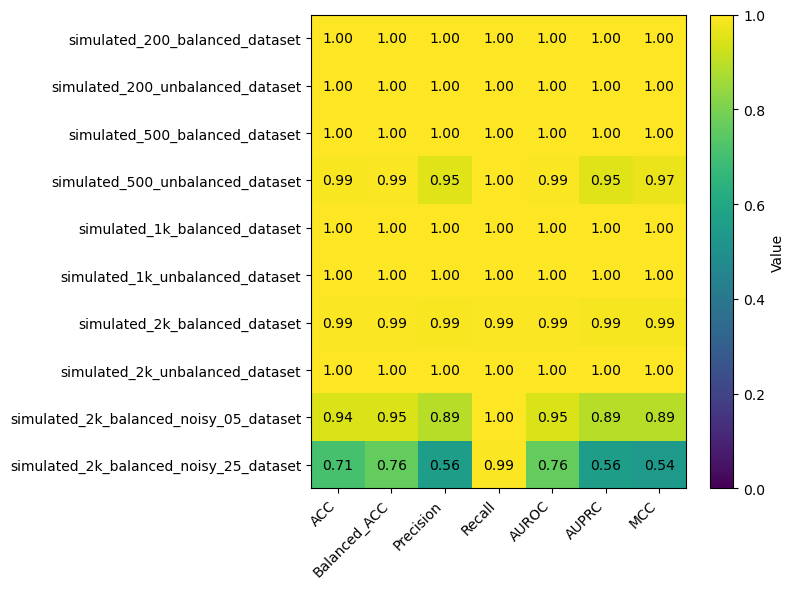

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(df_metrics.values, aspect="auto", vmin=0, vmax=1)

for i in range(df_metrics.shape[0]):
    for j in range(df_metrics.shape[1]):
        ax.text(
            j, i, f"{df_metrics.values[i, j]:.2f}",
            ha="center", va="center", color="black"
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Value")

# Ticks and labels
ax.set_xticks(np.arange(df_metrics.shape[1]))
ax.set_yticks(np.arange(df_metrics.shape[0]))
ax.set_xticklabels(df_metrics.columns)
ax.set_yticklabels(df_metrics.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()